In [ ]:
# # Plot animation

# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.animation as animation


# def plotani(imgs, titles=None, interval=400, cmap='gray',
#               vmin=None, vmax=None):
#     """
#     Create an animated figure from a list or array of images.

#     Parameters
#     ----------
#     imgs : list or np.ndarray
#         List or array of 2D images, shape (N, Nx, Ny)
#     titles : list of str, optional
#         Title for each frame
#     interval : int
#         Time between frames in ms
#     cmap : str
#         Colormap
#     vmin, vmax : float, optional
#         Intensity limits (recommended to avoid flicker)
#     """

#     imgs = np.asarray(imgs)

#     # magnitude if complex
#     if np.iscomplexobj(imgs):
#         imgs = np.abs(imgs)

#     if vmin is None:
#         vmin = np.percentile(imgs, 2)
#     if vmax is None:
#         vmax = np.percentile(imgs, 98)

#     fig, ax = plt.subplots()
#     im = ax.imshow(imgs[0], cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.axis('off')

#     def update(frame):
#         im.set_data(imgs[frame])
#         if titles is not None:
#             ax.set_title(titles[frame])
#         return [im]

#     ani = animation.FuncAnimation(
#         fig,
#         update,
#         frames=len(imgs),
#         interval=interval,
#         blit=True
#     )

#     plt.show()
#     return ani


In [ ]:
# progession plot
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

def plotp(images, titles=None, fig_title='',vmax=None):
    def view_image(i):
        plt.figure(figsize=(8, 8))
        # plt.imshow(images[i], cmap='gray', vmin=0, vmax=np.percentile(images[0], 99))
        if vmax is None:
            vmax = np.max(np.abs(images[i]))
        plt.imshow(abs(images[i])/vmax, cmap='gray')
        if titles is not None:
            plt.title(f"image {i}: {titles[i]}")
        plt.axis('off')
        plt.suptitle(fig_title, fontsize=14, fontweight='bold', y=0.95)
        plt.show()

    # interact(view_image, i=IntSlider(min=0, max=len(images)-1, step=1, value=0))
    interact(view_image, i=(0 , len(images)-1, 1))

# Usage:
# browse_progression([img1, img2, img3], ["Raw", "LLR-0.01", "LLR-0.1"])

In [6]:
# 3D windowed Plot
from ipywidgets import interact, FloatSlider, IntSlider
import matplotlib.pyplot as plt
import numpy as np

def plotw(volume, title="Recon Viewer", rotate=True , max_val=None,min_val=None, dynasdcm=False, norm=False):
    # 1. Move to CPU and handle complex data
    if hasattr(volume, 'get'): 
        volume = volume.get()
    
    # 2. Rotation to match Siemens Orientation (Optional but recommended)
    # This aligns with the 'R >> L' phase encoding in your protocol
    if rotate:
        volume=np.flip(volume,axis=-3)
        volume=np.rot90(volume,k=-1,axes=(1,2))
        volume=np.flip(volume,axis=-2)
    
    volume_abs = np.abs(volume)
    
    # # 3. CRITICAL: Remove NaNs/Infs for statistics
    # clean_data = volume_abs[np.isfinite(volume_abs)]
    
    # if clean_data.size == 0:
    #     print("Error: All values in volume are NaN or Inf.")
    #     return



    #Normalize and  Set the same dynamic range as siemens dicom if dynasdcm is set to True
    
    if norm:
        volume_abs_min=np.min(volume_abs)
        volume_abs_max=np.max(volume_abs)
        volume_abs=(volume_abs-volume_abs_min)/(volume_abs_max-volume_abs_min)
        if dynasdcm:
            max_val=1400
            min_val=0
            volume_abs*=max_val
        else:
            max_val=1
            min_val=0


    # 4. Calculate robust display limits
    # 99th percentile prevents "bright spot" artifacts from ruining contrast
    if max_val is None:
        # max_val = float(np.percentile(clean_data, 99))
        max_val = float(np.percentile(volume_abs, 99))
    if min_val is None:
        # min_val = float(np.percentile(clean_data, 1)) # Suggested noise floor
        min_val = float(np.percentile(volume_abs, 1)) # Suggested noise floor
    

    # if np.isnan(max_val) or max_val <= 0:
    #     max_val = 1.0 

    


    def update_view(slice_idx, v_min, v_max):
        # # Prevent v_min from being higher than v_max
        # if v_min >= v_max:
        #     v_min = v_max - (v_max * 0.01)
        fontsize=5
        plt.figure(figsize=(2, 2),dpi=250)
        # vmin and vmax control the windowing
        plt.imshow(volume_abs[slice_idx, :, :], cmap='gray', vmin=v_min, vmax=v_max)
        plt.title(f"{title} | Slice: {slice_idx}",fontsize=fontsize)
        cbar=plt.colorbar()
        cbar.set_label('Signal', fontsize=fontsize)
        cbar.ax.tick_params(labelsize=fontsize)
        
        plt.axis('off')
        plt.show()

    # 5. Create sliders for both min (black level) and max (white level)
    interact(update_view, 
             slice_idx=IntSlider(min=0, max=volume.shape[0]-1, step=1, value=volume.shape[0]//2),
             v_min=FloatSlider(min=0, max=max_val, step=max_val/100, value=0, description='Min (Black)'),
             v_max=FloatSlider(min=max_val/100, max=max_val*3, step=max_val/100, value=max_val, description='Max (White)'))


In [7]:
#single image plot
import matplotlib.pyplot as plt

def plot (data,rotate=True):
    if rotate:
        # data=np.flip(data,axis=-3)
        data=np.rot90(data,k=-1,axes=(-2,-1))
        data=np.flip(data,axis=-2)
        pass

    plt.figure()
    plt.imshow(abs(data),cmap='gray')

In [29]:
#plot grid
import matplotlib.pyplot as plt
import numpy as np

def plotg(images, titles=None, subtitle=None, cmap='gray', vmin=None, vmax=None, colorbar=True):
    """
    Plots a list of images in a dynamic subplot grid.
    
    Parameters:
    - images: List of 2D numpy arrays.
    - titles: List of strings for each subplot.
    - cmap: Colormap (default 'gray').
    - vmin/vmax: Windowing levels. If None, scales to each image's min/max.
    """
    n = len(images)
    if n == 0: return

    # 1. Calculate grid size (trying to keep it as square as possible)
    # cols = int(np.ceil(np.sqrt(n)))
    cols = 2
    rows = int(np.ceil(n / cols))

    # 2. Create figure
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    
    # Flatten axes array for easy iteration if n > 1
    if n > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i in range(n):
        ax = axes_flat[i]
        im = ax.imshow(abs(images[i]), cmap=cmap, vmin=vmin, vmax=vmax)
        
        # Minimize Title
        if titles and i < len(titles):
            ax.set_title(titles[i], fontsize=10, pad=4)
        
        ax.axis('off') # Cleaner for MRI

        # Minimize Colorbar
        if colorbar:
            cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
            cbar.ax.tick_params(labelsize=8)

    # 3. Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    if subtitle is not None:
        plt.suptitle(subtitle)
    plt.show()

# --- Example Usage ---
# images_to_plot = [img_raw, img_whitened, img_denoised]
# labels = ["Raw", "Whitened", "Denoised (LLR)"]
# plot_mri_grid(images_to_plot, titles=labels, vmin=0, vmax=500)

In [9]:
#Dicom images 
from pydicom import dcmread

file_dcm='/home/hpc/iwbi/iwbi112h/LLR_Daten/HighResMelon/dicom/100_wip_Snap_Cai_4_3_1-1-2_1p00_53_MR/9.dcm'

dcm=dcmread(file_dcm).pixel_array
print(np.shape(dcm))
img_dcm=dcm[36,...]
plotw(dcm,'Dicom ',rotate=False)

(70, 448, 360)


interactive(children=(IntSlider(value=35, description='slice_idx', max=69), FloatSlider(value=0.0, description…

In [10]:
import h5py
import numpy as numpy

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_Data/'
# file='CEST_GRAPPA_recons_65.h5' # clipped grappa for 65 Reps 
file='CEST_GRAPPA_recons_Rep_idx_9_ker_8x8.h5'
RO=224
REP=9
imgs=[]
RO_start=15 #start and end RO positin that cover FOV
RO_end=205
# RO_end=163
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    for RO_idx in range(RO_start,RO_end): 
        # imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}_8x8'][REP,:,:])
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][0,:,:])

# min_val=np.min(abs(np.array(imgs)))
# max_val=np.max(abs(np.array(imgs)))

imgs=np.array(imgs)
print('imgs shape:',imgs.shape)
print(f'orignal dyn. range: {np.min(abs(imgs))} - {np.max(abs(imgs))} ')
imgs=np.permute_dims(imgs,(1,2,0))
print('imgs shape:',imgs.shape)
# plotw(imgs,min_val=min_val,max_val=max_val)
# plotw(imgs,'GRAPPA',dynasdcm=False, norm=True )
plotw(imgs,'GRAPPA',dynasdcm=False, norm=False )
img_g=imgs[36,...]

imgs shape: (190, 72, 180)
orignal dyn. range: 7.639679324711324e-07 - 0.0006604218506254256 
imgs shape: (72, 180, 190)


interactive(children=(IntSlider(value=36, description='slice_idx', max=71), FloatSlider(value=0.0, description…

In [11]:
import h5py
import numpy as numpy

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_Data/'
# file='CEST_GRAPPA_recons_65.h5' # clipped grappa for 65 Reps 
file='CEST_GRAPPA_recons_Rep_idx_9_ker_8x8_prew.h5'
RO=224
REP=9
imgs=[]
RO_start=15 #start and end RO positin that cover FOV
RO_end=205
# RO_end=163
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    for RO_idx in range(RO_start,RO_end): 
        # imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}_8x8'][REP,:,:])
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][0,...])

imgs=np.array(imgs)
print('imgs shape:',imgs.shape)
imgs=np.permute_dims(imgs,(1,2,0))
print('imgs shape:',imgs.shape)
# plotw(imgs,min_val=min_val,max_val=max_val)
plotw(imgs,'Prewhiten_GRAPPA',norm=False)
img_gp=imgs[36,...]

imgs shape: (190, 72, 180)
imgs shape: (72, 180, 190)


interactive(children=(IntSlider(value=36, description='slice_idx', max=71), FloatSlider(value=0.0, description…

In [ ]:
img_gn=(img_g-np.min(np.abs(img_g)))/(np.max(np.abs(img_g))-np.min(np.abs(img_g)))
img_gpn=(img_gp-np.min(np.abs(img_gp)))/(np.max(np.abs(img_gp))-np.min(np.abs(img_gp)))
plotw((img_gpn-img_gn)[None,...],'difference of Prewhiten')

interactive(children=(IntSlider(value=0, description='slice_idx', max=0), FloatSlider(value=0.0, description='…

In [ ]:
# interpolate pixels to double the size 
import sigpy as sp
img_gp_fft=sp.fft(img_gp, axes=[-1,-2]) #gp:grappa prewhitenen
shape=img_gp_fft.shape
print(shape)
img_gp_fft=sp.resize(img_gp_fft,(shape[-2]*2,shape[-1]*2))
print(img_gp_fft.shape)
img_gp_int=sp.ifft(img_gp_fft,axes=[-1,-2])

# img_2_int=np.rot90(img_2_int,k=-1,axes=(-2,-1))
# img_2_int=np.flip(img_2_int,axis=-2)
plotw(img_gp_int[None, ...],'Zero Padded_GRAPPA')


(180, 190)
(360, 380)


interactive(children=(IntSlider(value=0, description='slice_idx', max=0), FloatSlider(value=0.0, description='…

In [14]:
from skimage.restoration import (denoise_bilateral,denoise_tv_chambolle ,denoise_wavelet)

# img_2_de=denoise_bilateral(abs(img_2_int),sigma_spatial=15, channel_axis=None)
img_gpi_den=denoise_tv_chambolle(abs(img_gp_int),weight=2 ,channel_axis=None)
# img_2_de=denoise_wavelet(abs(img_2_int),channel_axis=None,method='BayesShrink', mode='soft',rescale_sigma=True)

plotw(img_gpi_den[None,...], 'Interp,denoised, GRAPPA')

interactive(children=(IntSlider(value=0, description='slice_idx', max=0), FloatSlider(value=0.0, description='…

In [15]:
#rotate Dicom to  other .dat images 
def rot (volume):
    volume=np.rot90(volume,k=-1,axes=(-2,-1))
    volume=np.flip(volume,axis=-2)
    return volume
    

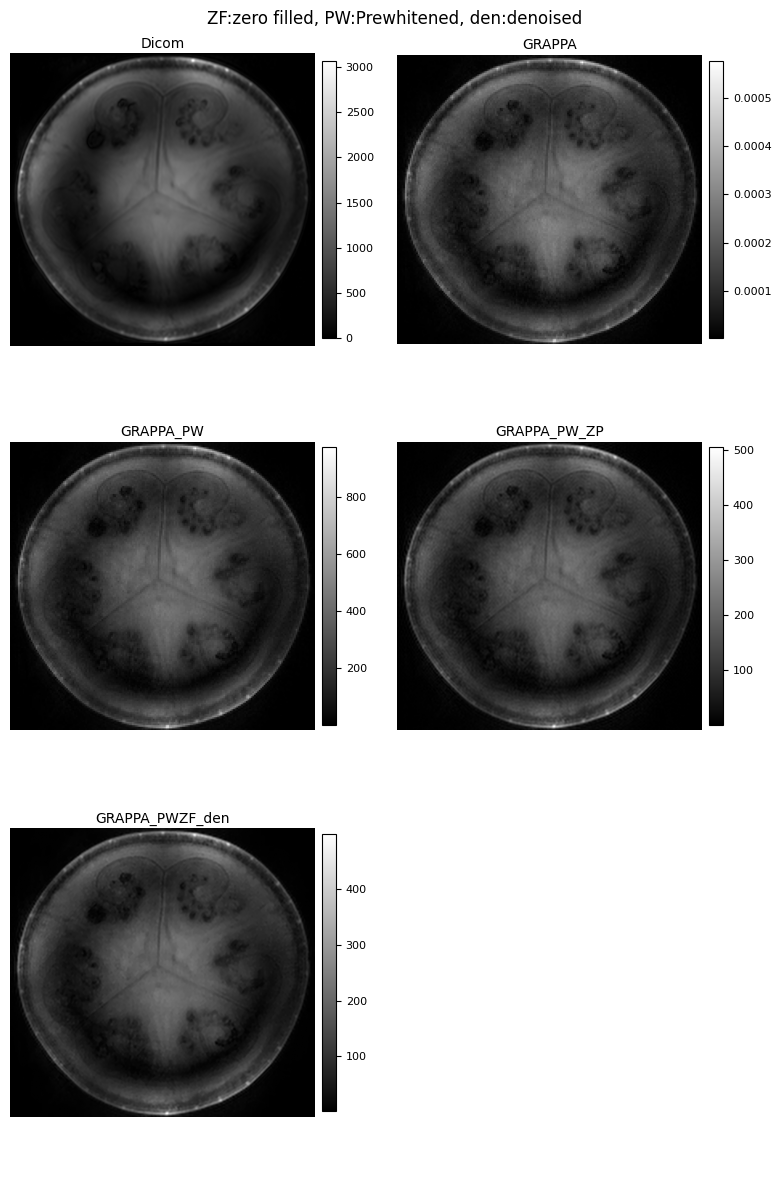

interactive(children=(IntSlider(value=0, description='i', max=4), Output()), _dom_classes=('widget-interact',)…

In [16]:

plotg([rot(abs(img_dcm[40:415,...])),abs(img_g),abs(img_gp),abs(img_gp_int),abs(img_gpi_den)],(['Dicom','GRAPPA','GRAPPA_PW','GRAPPA_PW_ZP','GRAPPA_PWZF_den']),'ZF:zero filled, PW:Prewhitened, den:denoised')
plotp([rot(abs(img_dcm[40:415,...])),abs(img_g),abs(img_gp),abs(img_gp_int),abs(img_gpi_den)],['Dicom','GRAPPA','GRAPPA_PW','GRAPPA_PW_ZP','GRAPPA_PWZF_den'], fig_title='ZF:zero filled, PW:Prewhitened, den:denoised')

In [ ]:
import h5py
import numpy as numpy

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_Data/'
# file='CEST_GRAPPA_recons_65.h5' # clipped grappa for 65 Reps 
file='CEST_CS_recons_9_r_1e-08_i_20_mapc_0.6.h5'
# file='CEST_LLR_recons_65_1x6x6.h5'
# file='CEST_LLR_recons_65_1x1x1.h5'
RO=224
REP=9
imgs=[]
RO_start=15 #start and end RO positin that cover FOV
RO_end=205
# RO_end=146
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    for RO_idx in range(RO_start,RO_end): 
        # imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}_8x8'][REP,:,:])
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][0,...])

imgs=np.array(imgs)
print('imgs shape:',imgs.shape)
imgs=np.permute_dims(imgs,(1,2,0))
print('imgs shape:',imgs.shape)
# plotw(imgs,min_val=min_val,max_val=max_val)
plotw(imgs,'',norm=False)
img_CS=imgs[36,...]

imgs shape: (190, 72, 180)
imgs shape: (72, 180, 190)


interactive(children=(IntSlider(value=36, description='slice_idx', max=71), FloatSlider(value=0.0, description…

In [ ]:
# img_2_res = np.pad(img_2, ((0, 0), (0, img_1.shape[1]- img_2.shape[1] )), mode='constant', constant_values=0)
plotg(abs(img_2_res),abs(img_CS),abs(img_gpi_den)],(['LLR 1x5x5','CS','GRAPPA_PWZF_den']),'CS:Compress Sensing ,ZF:zero filled, PW:Prewhitened, den:denoised')

NameError: name 'img_2' is not defined

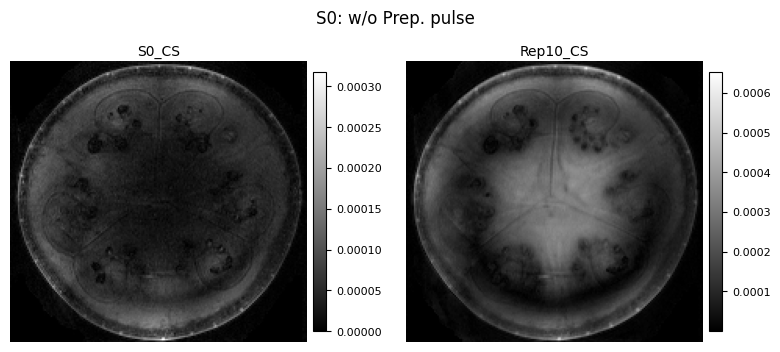

In [ ]:
img_s0_CS=np.load (DATA_DIR+'CEST_S0_CS_r_1e-8_i_20_axsl_36.npy')
plotg([abs(img_s0_CS[:,15:205]),abs(img_3)],['S0_CS','Rep10_CS'],'S0: w/o Prep. pulse')

In [ ]:
print(img_s0_CS.shape)
print(img_3.shape)

(180, 224)
(180, 190)


In [ ]:
# # individual sagital Slice view 

# import h5py
# import numpy as np

# DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_Data/'
# # file='CEST_recons_65.h5'
# file='CEST_LLR_recons_65_1x6x6.h5'
# # CEST_LLR_recons_65_1x1x1.h5
# RO=224
# REP=64
# imgs=[]
# RO_start=18 #start and end RO positin that cover FOV
# RO_end=205
# with h5py.File(DATA_DIR+file,'r') as f:
#     # print(f.keys())
# #     for RO_idx in range(RO_start,RO_end): 
# #         imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:])
#     RO_idx=100
#     img=f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:]

# print(np.shape(imgs))
# plot(img)
# # imgs=np.array(imgs)
# # imgs=np.permute_dims(imgs,(1,2,0))
# # print('imgs shape:',imgs.shape)
# # plotw(imgs)

recons shape: (6, 72, 180, 80)


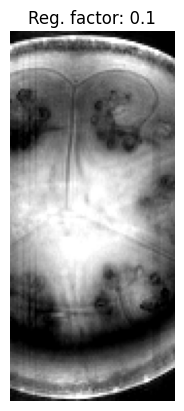

In [61]:
#Axial view
import h5py
import numpy as np

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_Data/'
# file='CEST_recons_65.h5'
# file='CEST_LLR_recons_65_1x1x1.h5'
# file='CEST_LLR_recons_65_1x6x6.h5'
# CEST_LLR_recons_65_1x1x1.h5
# file= 'CEST_LLR_recons_15_1x1x1_r_1e-06_i20.h5'
# file= 'CEST_LLR_recons_15_1x1x1_r_1e-06_i30.h5'
# file= 'CEST_LLR_recons_15_1x1x1_r_0.01_i20.h5'
# file= 'CEST_CS_recons_15_r_1e-08_i_20.h5'
# file= 'CEST_CS_recons_9_r_1e-08_i_20_mapc_0.6.h5'
# file= 'CEST_CS_recons_15_r_1e-08_i_30.h5'
# file= 'CEST_CS_recons_15_r_1e-10_i_20.h5'
# file= '/home/hpc/iwbi/iwbi112h/LLR codebooks/kdat/recons/recons_L1W.h5'
# file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x2x2_r_1e-06_i_30.h5'

reg_fctrs=[0.1,0.01,0.001,0.0001,1e-5, 1e-6]
file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x5x5_r_0.0001_i_30.h5'

RO=224
REP=8
recons=[]
imgs=[]
RO_start=80 #start and end RO position that cover FOV (0 || 15 || 80)
RO_end=160  # ( 146 || 160 || 205 || 244 )
# RO_end=146

for i in range(len(reg_fctrs)):
    with h5py.File(DATA_DIR+f'CEST_LLR_recons_Reps_1_10_RO_80_160_1x5x5_r_{reg_fctrs[i]}_i_30.h5','r') as f:
    # with h5py.File(DATA_DIR+file,'r') as f:
        # print(f.keys())
        for RO_idx in range(RO_start,RO_end): 
            imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:])
        # # RO_idx=1
        # img=f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:]
        # img=f[f'recons_L1W'][:]
        imgs=np.permute_dims(imgs,(1,2,0))
        recons.append(imgs)
        imgs=[]
    # print(np.shape(imgs))
    # imgs=np.array(imgs)
print('recons shape:',np.shape(recons))
# plotp([ recons[i][36,...], [f'Reg. factor: {reg_fctrs[i]}'] for i in range(len(reg_fctrs))])
imgs = [recons[i][36, ...] for i in range(len(reg_fctrs))]
titles = [f'Reg. factor: {r}' for r in reg_fctrs]

# plotp(imgs, titles)
ani=plotani(imgs, titles,interval=2)
from IPython.display import HTML
HTML(ani.to_jshtml())

ani.save('LLR_5x5_regs.gif', fps=.5, writer='pillow')
# plotw(np.squeeze(imgs))


In [ ]:
#Axial view
import h5py
import numpy as np

DATA_DIR='/home/vault/iwbi/iwbi112h/CEST_Data/'
# file= 'CEST_recons_65.h5'
# file= 'CEST_GRAPPA_recons_65.h5'
# file= 'CEST_LLR_recons_65_1x1x1.h5' #the one with severe artifacts
# file= 'CEST_LLR_recons_65_1x6x6.h5'
# file=' CEST_LLR_recons_65_1x1x1.h5
# file= 'CEST_LLR_recons_15_1x1x1_r_1e-06_i20.h5'
# file= 'CEST_LLR_recons_15_1x1x1_r_1e-06_i60.h5'
# file= 'CEST_LLR_recons_15_1x1x1_r_0.01_i20.h5'
# file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x12x12_r_1e-06_i_30.h5'
# file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x5x5_r_0.0001_i_30.h5'
file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x5x5_r_0.01_i_200.h5'
# file= 'CEST_LLR_recons_Reps_1_10_RO_1_160_1x2x2_r_0.1_i_30.h5'

RO=224
REP=8
imgs=[]
RO_start=80 #start and end RO position that cover FOV (0 || 15 || 80)

RO_end=160  # ( 146 || 160 || 205 || 244 )
with h5py.File(DATA_DIR+file,'r') as f:
    # print(f.keys())
    for RO_idx in range(RO_start,RO_end): 
        imgs.append(f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:])
    # RO_idx=1
    # img=f[f'CEST_recon_RO_idx_{RO_idx}'][REP,:,:]

# print(np.shape(imgs))
imgs=np.array(imgs)
imgs=np.permute_dims(imgs,(1,2,0))
print('imgs shape:',imgs.shape)

plotw(imgs,'5x5 _r 0.01 _i200')


imgs shape: (72, 180, 80)


interactive(children=(IntSlider(value=36, description='slice_idx', max=71), FloatSlider(value=0.0, description…

In [ ]:
# import sys
# import os
# bart_python_path = '/home/woody/iwbi/iwbi112h/USER-SPACK/opt/linux-ubuntu24.04-x86_64_v3/gcc-13.3.0/bart-0.7.00-lkbpv5zad56b5vo2lro2xpt5ikp7g4oh/lib/python3.11/site-packages'
# sys.path.insert(0, bart_python_path)
# import bart

# # ref_bart=np.permute_dims(ref_zf,[3,2,1,0])
# # print(np.shape(ref_bart))
# # ref_cc = ref_bart #skipping compression

# # bart.bart(0,'bart ') # bart(<#out_arg>,'commands',<input>,...)

In [ ]:
# import matplotlib.pyplot as plt
# import cfl
# import numpy as np
# import sigpy as sp
# imgs=bart.cfl.readcfl('recon')
# # imgs=cfl.readcfl('recon_sr00')
# # imgs=cfl.readcfl('recon_ssb')
# # imgs=cfl.readcfl('recons_ssb_fina__builtins__l')
# # imgs=np.permute_dims(imgs.squeeze(),(2,1,0))
# np.shape(imgs)
# # imgs=imgs/np.max(np.abs(imgs))
# # plt.figure(10)
# # plt.imshow(abs(imgs).T,cmap|='gray')
# # plotw(imgs[None,...])

# plotw(np.permute_dims(imgs.squeeze(),(1,0,2)))
# # plotw(np.permute_dims(imgs.squeeze(),(2,1,0)))
# # plotw(imgs)